# Notebook For Figure 6

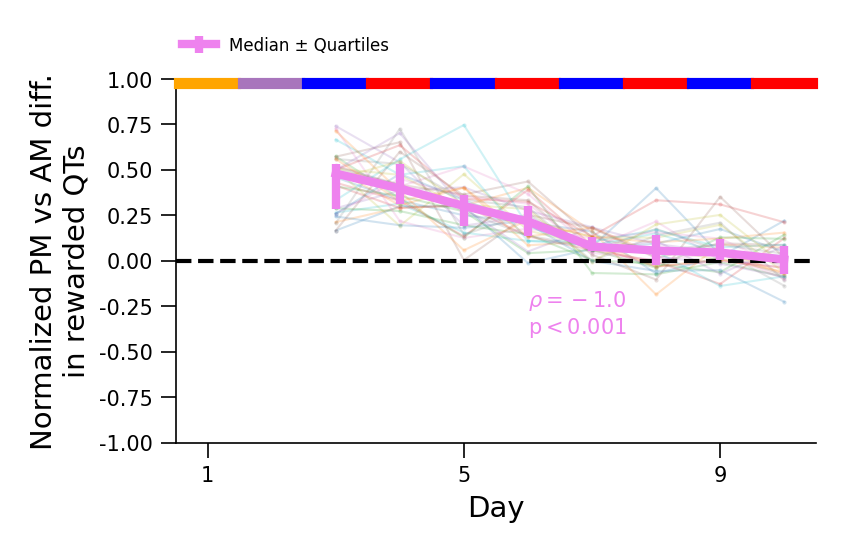

In [11]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("FigureS08.png")
display(img)


# 1. Imports necessary libraries and functions

In [2]:
import os
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec
import numpy as np
import pickle
import similaritymeasures as sm
from bisect import bisect
from scipy.stats import spearmanr
from scipy.stats import wilcoxon

plt.style.use('paper.mplstyle')


In [3]:
plotintermediatesteps = False

# 2. Select mice to analyse
### Define the data_folder where your MOU* folders are, generate a list of MOU* folders and for each mouse generate a list of all the sessions recorded

In [4]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

# path_to_data_folder='/home/david/MyLocalData/4TowersTask_MethodPaper/Group2Data'
# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/AurelienData/'
path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group2Data/'
# path_to_data_folder='/home/tom/Thèse/Data/ForagingMice/4TowerTaskMethodPaper/Group2Data/'
path_to_data_folder = os.path.abspath("C:/Users/FlowUP_Moll-E/Documents/Thèse/Données/ForagingMice/4TowerTaskMethodPaper/Group2Data")

# Analysing the entire group of mice
mice_to_analyse = ['MOU3974','MOU3975', 'MOU3987', 'MOU3988', 'MOU3991', 'MOU3992', 'MOU4551', 'MOU4552', 'MOU4560', 'MOU4561', 'MOU4562',
                   'MOU4563', 'MOU4623', 'MOU4964', 'MOU4965', 'MOU4986', 'MOU4987', 'MOU4988', 'MOU4993', 'MOU5007', 'MOU5008','MOU5130',
                   'MOU5131', 'MOU5136', 'MOU5140', 'MOU5142', 'MOU5143', 'MOU5144', 'MOU5145', 'MOU5148', 'MOU5149', 'MOU5158']

# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
# The last sessions will be analysed from index first_and_last_session_indexes[0] (included) to first_and_last_session_indexes[1] (excluded). 
first_and_last_session_indexes = [0,20]
# Select the number of sessions that will be in statistics
first_and_last_day_indexes_stats = [2,10]
# Setting the seed for random processes used in statistics
seed = 27
np.random.seed(seed)

All mice folders are present in data folder.
 32 mice will be analysed



The rewarding direction alternation (every day with 2 sessions per day) starts on session 5. In this session, some mice where rewarded in CW, and others in CCW. Mice that were rewarded in CCW were reversed in CW. This results in having all the mice treated as if they had the same rewarding direction.

# 3. Definition of functions

### General functions

In [5]:
def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54

def filter_qts(qts):

    """
    Filter out QTs with length above threshold and during which more than 1 switch occured.

    Arguments:
        qts (list): list of QTs (in the original format from the pickle)

    return:
        (list): list of filtered QTs
    """

    filtered_qts = []
    
    for qt in qts:

        # Skip current QT if there is more than 1 switches
        if qt[3]['num_trapezeswitch']!=1:
            
            continue
        
        # Skip current QT if it is longer than a threshold length (30 cm)
        if qt[4]['epoch_distance']>30:

            continue

        # Keep current QT if it did not check the removal conditions
        filtered_qts.append(qt)

    return filtered_qts

def count_qts(qts):

    total_qts = len(qts)
    cw_qts = 0
    rewarded_qts = 0

    for qt in qts:

        if qt[3]['direction']=='CW':

            cw_qts += 1

        if qt[3]['Rewarded']:

            rewarded_qts += 1

    return total_qts, cw_qts, rewarded_qts

def finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index, start_session_index=0):
    
    """
    Determines the rewarded direction for the last session of a given mouse.
    In the protocol this notebook is used for, the rewarded direction of the 
    last session is the same as in all the sessions where rewarding is allowed. 
    
    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse sessions folders.
        session_index (int): Index of the session that will be used to define the rewarded direction
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list 

    Returns:
        str: 'CW' (Clockwise) if the rewarded direction is 270 degrees,
             'CCW' (Counterclockwise) if the rewarded direction is 90 degrees,
             numpy.nan if reward delivery is not allowed 
             None if an error occurs.
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[start_session_index:]

    # Load data from the last session
    session_traj_df, session_turns_df, session_param_df = load_data(folder_path_mouse_to_process, sessions_to_process[start_session_index+session_index])

    # Extract rewarded direction in degrees
    rewarded_direction_degrees = session_param_df["potentialRewardedDirections"][0]

    # Check if reward delivery is allowed
    if session_param_df["allowRewardDelivery"][0]:

        # Determine the rewarded direction based on the extracted value
        if rewarded_direction_degrees == '[270]':
            rewarded_direction = 'CW'  # Clockwise

        elif rewarded_direction_degrees == '[90]':
            rewarded_direction = 'CCW'  # Counterclockwise
            
        elif rewarded_direction_degrees == '[90, 270]':
            rewarded_direction = 'both'  # Both directions

        else:
            print('ERROR: Unexpected unique rewarded direction value:', rewarded_direction_degrees)
            return None  # Explicitly return None to indicate failure
    
    else:

        # Rewarded direction is set to X if reward delivery os not allowed
        rewarded_direction = 'X'

    return rewarded_direction





In [6]:
def plot_learning_curve_alt_direction_perday(mouse_metric_perday, ax, mice_list=None, wilcoxon_test_threshold=np.nan, start_day_index=0, mice_to_highlight=[], mice_to_highlight_labels=[None,None],
                                      show_individual_mice=True, median_color='black', show_xlabel=True, ylabel='', main_line_label=None,
                                      tick_interval=1, index_offset=0, xlim=[None,None], ylim=None, show_background_legend=False, show_legend=True):
    
    """
    Plots a given metric across days for multiple mice (also called a learning curves). Each session is color coded differently depending on
    it rewarding regime, and whether it happened it the morning or afternoon.

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        mice_to_highlight_labels (list, optional): List of the label of the mice to highlight.
        show_individual_mice (bool, optional): If true, plot a line for each individual mouse.
        session_limit (tuple, optional): Inrerval of session indexes to plot. Defaults to [None,None] (plot all sessions).
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis.
        main_line_label (str, optional): Label of the median and quartiles range.
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        index_offset (int, optional): Offset to apply to the numbers in the x axis. Use it if you want to the first sessions to be named '1'.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_background_legend (bool, optional): Whether to show the legend of the session color codes. Defaults to False.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_perday.keys())

    all_day_indexes = set()  # Track all session indices across selected mice
    values_per_day = {}  # Store values for each session across mice

    # Loop through each mouse and gather session data
    for mouse in mice_list:
        if mouse not in mouse_metric_perday:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of day to analyse
        days = mouse_metric_perday[mouse]

        # Extract session indices and corresponding values
        day_indexes = [day[0] for day in days]
        values = [day[1] for day in days]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:
    
            if mouse in mice_to_highlight: # Plot the values in opac dark orange or green if the current mouse is in mice_to_highlight
                highlight_colors = ["darkorange", "green"]
                color_idx = mice_to_highlight.index(mouse) if mice_to_highlight.index(mouse) < len(highlight_colors) else 0
                ax.plot(day_indexes, values, color=highlight_colors[color_idx], marker='o', linewidth=0.5, 
                        markersize=1, label=mice_to_highlight_labels[mice_to_highlight.index(mouse)], zorder=100*len(median_color))
            else:
                ax.plot(day_indexes, values, marker='o', linewidth=0.5, markersize=1, alpha=0.2, markeredgewidth=0.0)

        # Update session index tracking
        all_day_indexes.update(day_indexes)
        for day, value in days:
            if day not in values_per_day:
                values_per_day[day] = []
            values_per_day[day].append(value)

    # Convert session indices to a sorted list
    sorted_days = sorted(all_day_indexes)

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    p_value_list = []

    for day in sorted_days:
        day_values = np.array(values_per_day[day])
        median_values.append(np.nanmedian(day_values))
        lower_quartile.append(np.nanpercentile(day_values, 25))
        upper_quartile.append(np.nanpercentile(day_values, 75))
    
        if not(np.isnan(wilcoxon_test_threshold)):
        
            res = wilcoxon(day_values - wilcoxon_test_threshold, alternative='two-sided')
            p_value_list.append(res.pvalue*len(sorted_days))

    p_value_array = np.array(p_value_list)

    if not(np.isnan(wilcoxon_test_threshold)):

        # Find sessions where p-value is <0.05
        significant_data_mean_diff_list = np.where(p_value_array<0.05, np.array(median_values), np.nan)

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)



    # Find the first mouse of the sample. It will be used to determine the rewarded direction of the session
    folder_path_first_mouse = os.path.join(path_to_data_folder,list(mouse_metric_perday.keys())[0])

    # Initialize a set to contain colors that have already been shown in the legend
    used_colors = set([])

    # Iterate on the index of sessions
    for day_index in range(len(sorted_days)):
            
            # Fint the rewarded direction of the session
            rewarded_direction = finding_mouse_rewarded_direction(folder_path_first_mouse, day_index*2, start_day_index)

            # Checks if rewarding was available
            rewarding = rewarded_direction != 'X'

            # If there is no rewarding, color code the session in orange
            if not(rewarding):
                band_color = "orange"
                direction_label = "Familiarization" if show_background_legend else None

            # If both directions are rewarded, color code the session in purple
            elif rewarded_direction == "both":
                band_color = "#a875bc"
                direction_label = "Both rewarded directions" if show_background_legend else None

            # If the day is odd, color code the sessions in this day in blue
            elif day_index%2 < 1:
                band_color = "blue"
                direction_label = "CW rewarded direction" if show_background_legend else None

            # Else, color code them in red
            else:
                band_color = "red"
                direction_label = "CCW rewarded direction" if show_background_legend else None

            ax.axvspan(day_index+1 - 0.49, day_index+1 + 0.49, ymin=0.979, ymax=0.998,
                       color=band_color, zorder=3, clip_on=False, label = direction_label if not(band_color in used_colors) else None )

            # Add the color code to the used_colors set so that it will not appear several times on the legend
            used_colors.add(band_color)

    if not(np.isnan(wilcoxon_test_threshold)):

        ax.scatter(sorted_days, significant_data_mean_diff_list, color='#1f77b4', edgecolor='black', marker='*',s=20, linewidths=0.5,
               label=r'Wilcoxon p $< 0.05$', zorder=1000)
    
    # If the median and quartiles range don't have a label, give them a default label.
    if not main_line_label:

        main_line_label = f'Median \u00B1 Quartiles, n={len(mice_list)}'

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.errorbar(np.array(sorted_days)+index_offset, median_values, yerr=[median_values-lower_quartile, upper_quartile-median_values], alpha=1,
                color=median_color, linewidth = 2, label=main_line_label, zorder=50*len(median_color))

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Day', fontsize=7)
    
    ax.set_ylabel(ylabel, fontsize=7)

    # Ensure x-axis labels are integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_day_indexes:
        max_index = max(all_day_indexes)
        ax.set_xticks(range(1, max_index + 1, tick_interval))

    # Apply x and y axis limits if provided
    if xlim is not None:
        ax.set_xlim(xlim)
    
    if ylim is not None:
        ax.set_ylim(ylim)

    # Show legend if required
    if show_legend:

        if show_background_legend:
            # Organising background legend so that the Morning/Afternoon are shown first
            handles, labels = plt.gca().get_legend_handles_labels()
            current_order = list(range(len(handles)))
            target_order = current_order[1:3] + [current_order[0]] + current_order[3:]

            # Add a black outline only to the "Morning" patch
            for h, l in zip(handles, labels):
                if l == "Morning" and isinstance(h, plt.Rectangle):
                    h.set_edgecolor("black")
                    h.set_linewidth(0.2)

            ax.legend(
                [handles[idx] for idx in target_order],
                [labels[idx] for idx in target_order],
                frameon=False, fontsize=4, loc=(0,1.05), ncol=2
            )

        else:
            ax.legend(frameon=False, fontsize=4, loc=(0,1.05), ncol=2)

# 7. Whole figure 

In [7]:
def shuffled_spearman_test(mouse_values_persession, shuffle_number, hypothesis, illustration_mouse_name = None, first_and_last_session_indexes=[None,None]):
    
    """
    Compute the Spearman correlation coefficient of input session-wise data then compare it to a null distribution computed by shuffling
    the input data several times

    Arguments:
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    Return:
        (list): list containing the Spearman correlation coefficient of the unshuffled data and the p-value associaed to the test
    """

    # Selecting mice to analyse
    if illustration_mouse_name is None:
        illustration_mouse_name = list(mouse_values_persession.keys())

    ### Compute the Spearman correlation coefficient distribution by shuffling data ###

    # Initialize the list where the Spearman correlation coefficients from shuffled data will be stored. 
    # This will be the null distribution of Spearman correlation coefficient
    spearman_rho_list = []
    
    # Shuffle the data shuffle_number times
    for _ in range(shuffle_number):

        # Initialize the list that will contain shuffled data
        shuffled_values_list = []
        
        # Iterate on every mice
        for mouse in illustration_mouse_name:

            # Checking if the current mouse has no value to plot
            if mouse not in mouse_values_persession:
                print(f"Mouse {mouse} not found in data. Skipping.")
                continue    

            # Selecting sessions under the limit
            sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

            # Extract sessions number
            session_indices = [session[0] for session in sessions]
            # Extract and shuffle values 
            shuffled_values = np.random.choice([session[1] for session in sessions], size=len(sessions), replace=False)
            # Store the shuffled values
            shuffled_values_list.append(shuffled_values)

        # Compute the median over all the mice
        median_values = np.nanmedian(shuffled_values_list,axis=0)
        # Compute the Spearman correlation coefficient of the median
        spearman_result = spearmanr(session_indices, median_values)
        # Store the coefficient
        spearman_rho_list.append(spearman_result[0])
    
    ### Compute the Spearman correlation coefficient of unshuffled data ###
    values_list = []

    for mouse in illustration_mouse_name:

        # Checking if the current mouse has no value to plot
        if mouse not in mouse_values_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting sessions under the limit
        sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

        # Extract sessions number
        session_indices = [session[0] for session in sessions]

        # Extract values
        values = [session[1] for session in sessions]
        
        # Store the value
        values_list.append(values)

    # Compute the median over all the mice
    actual_median_values = np.nanmedian(values_list,axis=0)

    # Compute the Spearman correlation coefficient of the median
    actual_spearman_result = spearmanr(session_indices,actual_median_values, nan_policy='omit')
    actual_rho = actual_spearman_result[0]

    # Compute the p-value corresponding to the tested hypothesis
    if hypothesis=="increasing":
        # Computing the the proportion of the null distribution above the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[bisect(np.sort(spearman_rho_list), actual_rho):])/len(spearman_rho_list)
    elif hypothesis=="decreasing":
        # Computing the the proportion of the null distribution below the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[:bisect(np.sort(spearman_rho_list), actual_rho)])/len(spearman_rho_list)
    else:
        # Raise an error if no valid hypothesis was made
        print("ERROR : Invalid hypothesis. Please specify increasing or decreasing")
        return

    print(len(actual_median_values))

    return actual_rho, p_value

def plot_shuffled_spearman_test_res(ax, text_loc, mouse_values_persession, n_shuffles, hypothesis, color='black', illustration_mouse_name=None, first_and_last_session_indexes=[1,None]):

    """
    Plots the result of shuffled_spearman_test as a text on a figure.

    Arguments:
        ax (matplotlib.axes.Axes): Axes object for plotting
        text_loc (list): coordinate of the text (in data units)
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        color (str): Color of the text
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    """

    test_res = shuffled_spearman_test(mouse_values_persession, n_shuffles, hypothesis, illustration_mouse_name=illustration_mouse_name, first_and_last_session_indexes=first_and_last_session_indexes)    

    if test_res[1]==0:
        
        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ < 0.001$', fontsize=5, color=color) 

    else:

        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ = {round(test_res[1],3)}$', fontsize=5, color=color)

In [8]:
# Initialize dictionaries to store the various metrics for each mouse
mouse_rewarded_qts_persession = {mouse: [] for mouse in mice_to_analyse}
mouse_unrewarded_qts_persession = {mouse: [] for mouse in mice_to_analyse}

mouse_total_rewarded_norm_diff_perday = {mouse: [] for mouse in mice_to_analyse}
mouse_total_unrewarded_norm_diff_perday = {mouse: [] for mouse in mice_to_analyse}


# Iterate through each mouse to process its data
for mouse in mice_to_analyse:
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')


    # Process each session for the current mouse
    for session_index, session_to_process in enumerate(sessions_to_process):

        # Determine the rewarded direction for all sessions of the current mouse
        rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, first_and_last_session_indexes[0]+session_index)
        # Deterine the first unique rewarded direction of the session series
        first_rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, 4)

        # Define the pickle file path for the session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Extract run around tower results from the session data
        epochs = session_data['all_epochs']
        qts = filter_qts(epochs['run_around_tower'])
        total_qts, cw_qts, rewarded_qts = count_qts(qts)
        ccw_qts = total_qts - cw_qts
        ccw_vs_cw_norm_diff = (ccw_qts-cw_qts)/(total_qts)

        mouse_rewarded_qts_persession[mouse].append([session_index + 1, rewarded_qts])
        mouse_unrewarded_qts_persession[mouse].append([session_index + 1, total_qts-rewarded_qts])

    for day_index, i in enumerate(np.arange(0,int(len(sessions_to_process)),2)):

        total_rewarded = mouse_rewarded_qts_persession[mouse][i+1][1]+mouse_rewarded_qts_persession[mouse][i][1]
        total_unrewarded = mouse_unrewarded_qts_persession[mouse][i+1][1]+mouse_unrewarded_qts_persession[mouse][i][1]

        rewarded_norm_diff = (mouse_rewarded_qts_persession[mouse][i+1][1] - mouse_rewarded_qts_persession[mouse][i][1]) / total_rewarded if total_rewarded>0 else 0
        unrewarded_norm_diff = (mouse_unrewarded_qts_persession[mouse][i+1][1] - mouse_unrewarded_qts_persession[mouse][i][1]) / total_unrewarded if total_unrewarded>0 else 0

        if day_index<=1:
            rewarded_norm_diff = np.nan
            unrewarded_norm_diff = np.nan

        mouse_total_rewarded_norm_diff_perday[mouse].append([day_index+1,rewarded_norm_diff])
        mouse_total_unrewarded_norm_diff_perday[mouse].append([day_index+1,unrewarded_norm_diff])




Mouse MOU3974. There is/are 20 sessions:
['MOU3974_20230304-1314', 'MOU3974_20230305-1535', 'MOU3974_20230306-1211', 'MOU3974_20230306-1752', 'MOU3974_20230307-1231', 'MOU3974_20230307-1742', 'MOU3974_20230308-1150', 'MOU3974_20230308-1714', 'MOU3974_20230309-1155', 'MOU3974_20230309-1705', 'MOU3974_20230310-1220', 'MOU3974_20230310-1702', 'MOU3974_20230311-1258', 'MOU3974_20230311-1801', 'MOU3974_20230312-1145', 'MOU3974_20230312-1648', 'MOU3974_20230313-1129', 'MOU3974_20230313-1725', 'MOU3974_20230314-1036', 'MOU3974_20230314-1620'] 

Mouse MOU3975. There is/are 20 sessions:
['MOU3975_20230304-1329', 'MOU3975_20230305-1550', 'MOU3975_20230306-1228', 'MOU3975_20230306-1810', 'MOU3975_20230307-1249', 'MOU3975_20230307-1800', 'MOU3975_20230308-1206', 'MOU3975_20230308-1731', 'MOU3975_20230309-1209', 'MOU3975_20230309-1720', 'MOU3975_20230310-1234', 'MOU3975_20230310-1716', 'MOU3975_20230311-1311', 'MOU3975_20230311-1814', 'MOU3975_20230312-1158', 'MOU3975_20230312-1702', 'MOU3975_20230

C:\Users\FlowUP_Moll-E\AppData\Local\Temp\ipykernel_24288\1832966936.py:81: RuntimeWarning: All-NaN slice encountered
  median_values.append(np.nanmedian(day_values))
c:\Users\FlowUP_Moll-E\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1437: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


8


C:\Users\FlowUP_Moll-E\AppData\Local\Temp\ipykernel_24288\689906452.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


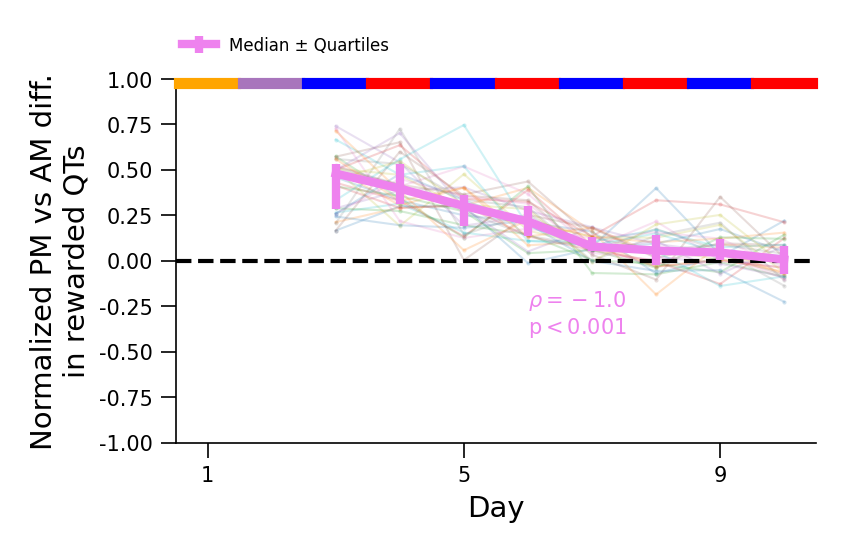

In [9]:
fig=plt.figure(figsize=(cm2inch(7), cm2inch(4)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(1, 1 , hspace=0.3)

tick_interval = 4

row1 = gs[:].subgridspec(1, 1)

ax_1 = plt.subplot(row1[:])

plot_learning_curve_alt_direction_perday(mouse_total_rewarded_norm_diff_perday, ax_1, wilcoxon_test_threshold=np.nan, ylabel='Normalized PM vs AM diff.\nin rewarded QTs', show_xlabel=True, show_background_legend=False, median_color='violet',
                                   main_line_label="Median \u00B1 Quartiles", tick_interval=tick_interval, xlim=[0.5,10.5], ylim=[-1,1])

plot_shuffled_spearman_test_res(ax_1, (6,-0.4), mouse_total_rewarded_norm_diff_perday, 1000, 'decreasing', color='violet', first_and_last_session_indexes=first_and_last_day_indexes_stats)    


ax_1.axhline(0,color='k', linestyle='--')

fig.align_ylabels()

fig.tight_layout()

plt.savefig("FigureS08.png", facecolor='w', edgecolor='none', bbox_inches='tight', format="png", dpi=300)


In [10]:
# Save the figure as a PDF
fig.savefig("FigureS08.pdf", format="pdf", bbox_inches='tight', dpi=300)
